# Exercício:

## 01 – Do exercício 2 da aula 15, exporte o objeto DataFrame contendo as frequências absolutas de cada aminoácido em cada proteína para .csv, instancie um objeto da classe DataFrame. Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas de tendência central. Qual o valor de média, mediana e moda da Serina nos genes analisados? E do terceiro gene?

In [13]:
import pandas as pd
df = pd.read_csv('/content/df_freq.csv', index_col=0)

def tendencia_central(vetor):
    media = vetor.mean()
    mediana = vetor.median()
    moda = vetor.mode()

    return {
        "media": media,
        "mediana": mediana,
        "moda": moda.tolist()  # pode ter mais de uma
    }

serina = tendencia_central(df['S'])
print(f"A média da Serina é {serina['media']}")
print(f"A mediana da Serina é {serina['mediana']}")
print(f"A moda da Serina é {serina['moda']}")

arr = tendencia_central(df.loc["arr"])
print(f"A média do gene arr é {arr['media']}")
print(f"A mediana do gene arr é {arr['mediana']}")
print(f"A moda do gene arr é {arr['moda']}")

A média da Serina é 23.4
A mediana da Serina é 21.0
A moda da Serina é [14]
A média do gene arr é 13.3
A mediana do gene arr é 11.0
A moda do gene arr é [3, 9, 11]


## 02 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a amplitude. Qual o valor de amplitude da Isoleucina? E do último gene?

In [14]:
def amplitude(vetor):
    return vetor.max() - vetor.min()

isoleucina = amplitude(df['I'])
print(f"A amplitude da Isoleucina é {isoleucina}")

ultimo_gene = amplitude(df.iloc[-1])
print(f"A amplitude do último gene é {ultimo_gene}")

A amplitude da Isoleucina é 45
A amplitude do último gene é 66


## 03 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne os quartis. Qual o valor do Q1, Q2 e Q3 da Metionina? E do primeiro gene?

In [18]:
def quartis(vetor):
    return {
        "Q1": vetor.quantile(0.25),
        "Q2": vetor.quantile(0.50),
        "Q3": vetor.quantile(0.75)
    }

metionina = quartis(df['M'])
print(f"O Q1 da Metionina é {metionina['Q1']}")
print(f"O Q2 da Metionina é {metionina['Q2']}")
print(f"O Q3 da Metionina é {metionina['Q3']}")

primeiro_gene = quartis(df.iloc[0])
print(f"O Q1 do primeiro gene é {primeiro_gene['Q1']}")
print(f"O Q2 do primeiro gene é {primeiro_gene['Q2']}")
print(f"O Q3 do primeiro gene é {primeiro_gene['Q3']}")

O Q1 da Metionina é 4.0
O Q2 da Metionina é 11.0
O Q3 da Metionina é 12.0
O Q1 do primeiro gene é 7.75
O Q2 do primeiro gene é 14.0
O Q3 do primeiro gene é 18.25


## 04 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o intervalo interquartil. Qual o valor do o intervalo interquartil da Ácido Glutâmico? E do penúltimo gene? Obtenha o box plot com as medidas de tendência central para a frequência de aa nesse gene.

O IQR da Ácido Glutâmico é 8.0
O IQR do penúltimo gene é 7.25


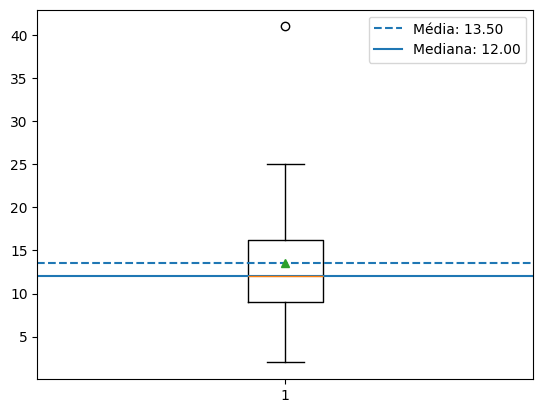

In [25]:
def iqr(vetor):
    q1 = vetor.quantile(0.25)
    q3 = vetor.quantile(0.75)
    return q3 - q1
iqr_e = iqr(df['E'])
print(f"O IQR da Ácido Glutâmico é {iqr_e}")

iqr_penultimo = iqr(df.loc["sul"])
print(f"O IQR do penúltimo gene é {iqr_penultimo}")


import matplotlib.pyplot as plt

dados = df.iloc[-2]
plt.boxplot(dados, vert=True, showmeans=True)
media = dados.mean()
mediana = dados.median()
plt.axhline(media, linestyle='--', label=f"Média: {media:.2f}")
plt.axhline(mediana, linestyle='-', label=f"Mediana: {mediana:.2f}")
plt.legend()
plt.show()


## 05 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne a variância amostral não viciada. Qual o valor da variância da Prolina? E do terceiro gene?

In [27]:
def variancia_amostral(vetor):
    return vetor.var(ddof=1)

prolina = variancia_amostral(df['P'])
print(f"A variância da Prolina é {prolina}")

terceiro_gene = variancia_amostral(df.iloc[2])
print(f"A variância do terceiro gene é {terceiro_gene}")


A variância da Prolina é 45.2
A variância do terceiro gene é 85.8


## 06 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o desvio padrão. Qual o valor d o desvio padrão do Triptofano? E do gene de index -1?

In [31]:
def desvio_padrao(vetor):
    return vetor.std(ddof=1)

dp_W = desvio_padrao(df["W"])
print(f"O desvio padrão do triptofano é {dp_W}")

dp_ultimo = desvio_padrao(df.iloc[-1])
print(f"O desvio padrão do último gene (adeN) é {dp_ultimo}")

O desvio padrão do triptofano é 1.3416407864998738
O desvio padrão do último gene (adeN) é 16.314265633423243


## 07 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne o coeficiente de variação. Qual o valor do coeficiente de variação da Leucina? E do gene de index 1?

In [33]:
def coeficiente_variacao(vetor):
    media = vetor.mean()
    dp = vetor.std(ddof=1)
    return dp / media

cv_L = coeficiente_variacao(df["L"])
print(f"O coeficiente de variação da Leucina é {cv_L}")

cv_gene1 = coeficiente_variacao(df.iloc[1])
print(f"O coeficiente de variação do gene 1 é {cv_gene1}")


O coeficiente de variação da Leucina é 0.5580794277758299
O coeficiente de variação do gene 1 é 0.7236360612519294


## 08 – Defina uma função que receba qualquer objeto composto unidimensional e que retorne as medidas resumo.
Obs.: Use um dicionário onde os index são os nomes e os valores as medidas.

In [34]:
def medidas_resumo(vetor):
    resumo = {
        "media": vetor.mean(),
        "mediana": vetor.median(),
        "moda": vetor.mode().tolist(),
        "min": vetor.min(),
        "max": vetor.max(),
        "amplitude": vetor.max() - vetor.min(),
        "Q1": vetor.quantile(0.25),
        "Q2": vetor.quantile(0.50),
        "Q3": vetor.quantile(0.75),
        "IQR": vetor.quantile(0.75) - vetor.quantile(0.25),
        "variancia": vetor.var(ddof=1),
        "desvio_padrao": vetor.std(ddof=1),
        "coef_variacao": vetor.std(ddof=1) / vetor.mean()
    }

    return resumo

## 09 – Defina uma função que retorne qual o gene com o maior CV de frequência de aminoácidos. Obtenha os boxplot dos genes. Os dados concordam? Porque?

/tmp/ipykernel_2949/966326531.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df.T, labels=df.index, showmeans=True)


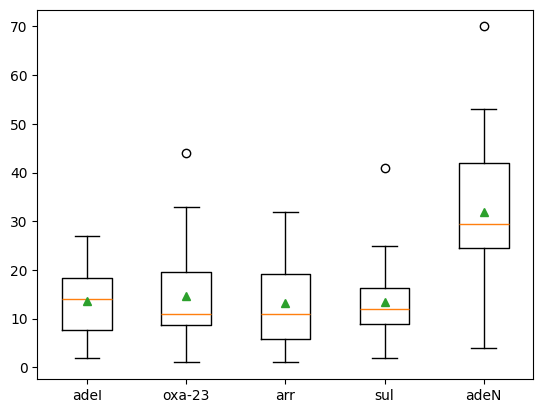

In [37]:
def gene_maior_cv(df):
    cvs = {}

    for gene in df.index:
        vetor = df.loc[gene]
        media = vetor.mean()
        dp = vetor.std(ddof=1)
        cv = dp / media

        cvs[gene] = cv

    maior_gene = max(cvs, key=cvs.get)

    return maior_gene, cvs

plt.boxplot(df.T, labels=df.index, showmeans=True)
plt.show()

Sim, os dados concordam. O gene com maior CV também apresenta maior dispersão no boxplot. Isso ocorre porque ambos medem variabilidade: o CV de forma relativa à média, e o boxplot de forma absoluta. Assim, maior variabilidade leva a valores mais espalhados nos dois casos.

## 10 – Defina uma função que retorne qual o aminoácidos com o maior CV dentre os genes. Obtenha os boxplot dos aminoácidos. Os dados concordam? Porque?

/tmp/ipykernel_2949/3408620091.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df.values, labels=df.columns, showmeans=True)


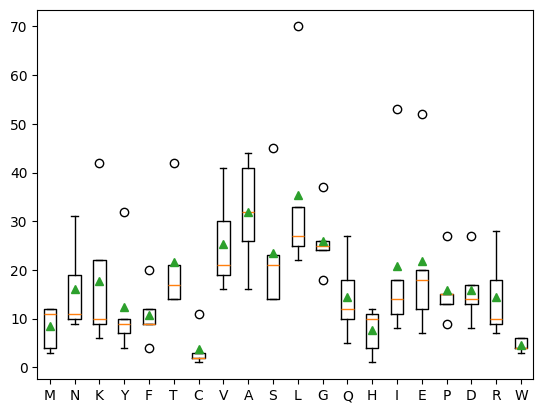

In [39]:
def aa_maior_cv(df):
    cvs = {}

    for aa in df.columns:
        vetor = df[aa]
        media = vetor.mean()
        dp = vetor.std(ddof=1)
        cv = dp / media

        cvs[aa] = cv

    maior_aa = max(cvs, key=cvs.get)

    return maior_aa, cvs


plt.boxplot(df.values, labels=df.columns, showmeans=True)
plt.show()


Sim. O aminoácido com maior CV também apresenta maior dispersão no boxplot, com maior espalhamento dos valores. Isso ocorre porque o CV mede a variabilidade relativa à média, enquanto o boxplot mostra a dispersão absoluta. Ambos indicam maior variabilidade para esse aminoácido.